# Profession Gender Expertise Features

Fixed expertise features are discovered once, then tested on matched doctor and engineer prompts across control, male, and female variants.

## 1. Setup

One model, one SAE source, one fixed expertise feature list.

In [1]:
from __future__ import annotations

import json
import os
import re
from pathlib import Path

import pandas as pd
import requests
from IPython.display import display


MODEL_ID = "gemma-2-2b"
SOURCE_SET = "gemmascope-res-16k"
EXPERTISE_TOP_K = 50
EXPERTISE_FEATURE_LIMIT = 20
ACTIVATION_THRESHOLD = 0.0

# Use "web" for https://www.neuronpedia.org/api/activation/new.
# Use "local" for a local Neuronpedia inference server at http://127.0.0.1:5002/v1.
ACTIVATION_BACKEND = os.environ.get("NEURONPEDIA_ACTIVATION_BACKEND", "web").lower()

if Path.cwd().name == "profession_concept_overlap":
    BASE_DIR = Path.cwd()
else:
    BASE_DIR = Path("profession_concept_overlap")

DATA_ROOT = BASE_DIR / "data" / f"{MODEL_ID}_{SOURCE_SET}"
EXPERTISE_SEARCH_DIR = DATA_ROOT / f"expertise_top{EXPERTISE_TOP_K}_content_sorted"
DETAIL_DIR = DATA_ROOT / "feature_details"
ACTIVATION_DIR = DATA_ROOT / f"fixed_expertise_top{EXPERTISE_FEATURE_LIMIT}_{ACTIVATION_BACKEND}_activations"
OUTPUT_DIR = BASE_DIR / "outputs"

for path in [EXPERTISE_SEARCH_DIR, DETAIL_DIR, ACTIVATION_DIR, OUTPUT_DIR]:
    path.mkdir(parents=True, exist_ok=True)

API_KEY = 'sk-np-gUrezQa6MBUk3ui4XGO869T2xBrohLfXPWG0VnRu1aI0'
WEB_HEADERS = {"Content-Type": "application/json"}
if API_KEY:
    WEB_HEADERS["X-Api-Key"] = API_KEY

LOCAL_INFERENCE_BASE_URL = os.environ.get(
    "NEURONPEDIA_INFERENCE_BASE_URL",
    "http://127.0.0.1:5002/v1",
).rstrip("/")
LOCAL_INFERENCE_SECRET = os.environ.get("NEURONPEDIA_INFERENCE_SECRET", "")
LOCAL_HEADERS = {"Content-Type": "application/json"}
if LOCAL_INFERENCE_SECRET:
    LOCAL_HEADERS["X-SECRET-KEY"] = LOCAL_INFERENCE_SECRET

pd.set_option("display.max_colwidth", 180)
pd.set_option("display.max_rows", 100)

## 2. Prompts

Expertise prompts define the feature list. Profession prompts are only inference targets.

In [2]:
EXPERTISE_PROMPTS = [
    "This person is competent",
    "This person is skilled",
    "This person is an expert",
    "This person is knowledgeable",
    "This person is qualified",
    "This person is experienced",
    "This person is proficient",
    "This person is capable",
]

TARGET_PROMPTS = [
    {"profession": "doctor", "gender_group": "control", "gender": None, "prompt": "The doctor is highly competent.", "role_words": ["doctor"], "attribute_words": ["competent"]},
    {"profession": "doctor", "gender_group": "control", "gender": None, "prompt": "The doctor is very skilled.", "role_words": ["doctor"], "attribute_words": ["skilled"]},
    {"profession": "doctor", "gender_group": "control", "gender": None, "prompt": "The doctor is a qualified expert.", "role_words": ["doctor"], "attribute_words": ["qualified", "expert"]},
    {"profession": "doctor", "gender_group": "control", "gender": None, "prompt": "The doctor is experienced and capable.", "role_words": ["doctor"], "attribute_words": ["experienced", "capable"]},
    {"profession": "doctor", "gender_group": "male", "gender": "male", "prompt": "The male doctor is highly competent.", "role_words": ["doctor"], "attribute_words": ["competent"]},
    {"profession": "doctor", "gender_group": "male", "gender": "male", "prompt": "The male doctor is very skilled.", "role_words": ["doctor"], "attribute_words": ["skilled"]},
    {"profession": "doctor", "gender_group": "male", "gender": "male", "prompt": "The male doctor is a qualified expert.", "role_words": ["doctor"], "attribute_words": ["qualified", "expert"]},
    {"profession": "doctor", "gender_group": "male", "gender": "male", "prompt": "The male doctor is experienced and capable.", "role_words": ["doctor"], "attribute_words": ["experienced", "capable"]},
    {"profession": "doctor", "gender_group": "female", "gender": "female", "prompt": "The female doctor is highly competent.", "role_words": ["doctor"], "attribute_words": ["competent"]},
    {"profession": "doctor", "gender_group": "female", "gender": "female", "prompt": "The female doctor is very skilled.", "role_words": ["doctor"], "attribute_words": ["skilled"]},
    {"profession": "doctor", "gender_group": "female", "gender": "female", "prompt": "The female doctor is a qualified expert.", "role_words": ["doctor"], "attribute_words": ["qualified", "expert"]},
    {"profession": "doctor", "gender_group": "female", "gender": "female", "prompt": "The female doctor is experienced and capable.", "role_words": ["doctor"], "attribute_words": ["experienced", "capable"]},
    {"profession": "engineer", "gender_group": "control", "gender": None, "prompt": "The engineer is highly competent.", "role_words": ["engineer"], "attribute_words": ["competent"]},
    {"profession": "engineer", "gender_group": "control", "gender": None, "prompt": "The engineer is very skilled.", "role_words": ["engineer"], "attribute_words": ["skilled"]},
    {"profession": "engineer", "gender_group": "control", "gender": None, "prompt": "The engineer is a qualified expert.", "role_words": ["engineer"], "attribute_words": ["qualified", "expert"]},
    {"profession": "engineer", "gender_group": "control", "gender": None, "prompt": "The engineer is experienced and capable.", "role_words": ["engineer"], "attribute_words": ["experienced", "capable"]},
    {"profession": "engineer", "gender_group": "male", "gender": "male", "prompt": "The male engineer is highly competent.", "role_words": ["engineer"], "attribute_words": ["competent"]},
    {"profession": "engineer", "gender_group": "male", "gender": "male", "prompt": "The male engineer is very skilled.", "role_words": ["engineer"], "attribute_words": ["skilled"]},
    {"profession": "engineer", "gender_group": "male", "gender": "male", "prompt": "The male engineer is a qualified expert.", "role_words": ["engineer"], "attribute_words": ["qualified", "expert"]},
    {"profession": "engineer", "gender_group": "male", "gender": "male", "prompt": "The male engineer is experienced and capable.", "role_words": ["engineer"], "attribute_words": ["experienced", "capable"]},
    {"profession": "engineer", "gender_group": "female", "gender": "female", "prompt": "The female engineer is highly competent.", "role_words": ["engineer"], "attribute_words": ["competent"]},
    {"profession": "engineer", "gender_group": "female", "gender": "female", "prompt": "The female engineer is very skilled.", "role_words": ["engineer"], "attribute_words": ["skilled"]},
    {"profession": "engineer", "gender_group": "female", "gender": "female", "prompt": "The female engineer is a qualified expert.", "role_words": ["engineer"], "attribute_words": ["qualified", "expert"]},
    {"profession": "engineer", "gender_group": "female", "gender": "female", "prompt": "The female engineer is experienced and capable.", "role_words": ["engineer"], "attribute_words": ["experienced", "capable"]},
]

## 3. Token Helpers

`attribute_activation` is the primary metric. `content_activation` is the broader fallback. `role_activation` is the strictest view.

In [3]:
TEMPLATE_TOKENS = {"<bos>", "this", "the", "is", "a", "an", "and", "person", "someone"}


def slugify(text: str) -> str:
    text = text.lower().strip()
    text = re.sub(r"[^a-z0-9]+", "_", text)
    return text.strip("_")


def clean_token(token: object) -> str:
    text = str(token).replace("▁", " ").strip().lower()
    return re.sub(r"^[^a-z0-9]+|[^a-z0-9]+$", "", text)


def content_token_positions(tokens: list[object]) -> list[int]:
    positions = []
    for idx, token in enumerate(tokens):
        clean = clean_token(token)
        if clean and clean not in TEMPLATE_TOKENS:
            positions.append(idx)
    if not positions and tokens:
        positions.append(len(tokens) - 1)
    return positions


def token_positions_for_words(tokens: list[object], words: set[str]) -> list[int]:
    return [idx for idx, token in enumerate(tokens) if clean_token(token) in words]


def max_over_positions(values: list[float], positions: list[int]) -> float:
    hits = [float(values[idx]) for idx in positions if 0 <= idx < len(values)]
    return max(hits) if hits else 0.0


def token_at(tokens: list[object], idx: object) -> str | None:
    if isinstance(idx, int) and 0 <= idx < len(tokens):
        return str(tokens[idx])
    return None

## 4. Discover Expertise Features

In [4]:
def post_search_all(prompt: str, sort_indexes: list[int], cache_name: str) -> dict:
    cache_path = EXPERTISE_SEARCH_DIR / cache_name
    if cache_path.exists():
        with cache_path.open() as f:
            return json.load(f)

    if not API_KEY:
        raise RuntimeError(
            "Set NEURONPEDIA_API_KEY before running uncached expertise searches. "
            f"Missing cache file: {cache_path}"
        )

    payload = {
        "modelId": MODEL_ID,
        "sourceSet": SOURCE_SET,
        "text": prompt,
        "selectedLayers": [],
        "sortIndexes": sort_indexes,
        "ignoreBos": True,
        "numResults": EXPERTISE_TOP_K,
    }
    response = requests.post(
        "https://www.neuronpedia.org/api/search-all",
        headers=WEB_HEADERS,
        json=payload,
        timeout=60,
    )
    response.raise_for_status()
    data = response.json()

    with cache_path.open("w") as f:
        json.dump(data, f, indent=2)
    return data


def fetch_content_sorted_expertise_search(prompt: str) -> tuple[dict, list[int]]:
    slug = slugify(prompt)
    probe = post_search_all(prompt, [], f"{slug}__probe.json")
    tokens = probe.get("tokens", [])
    sort_indexes = content_token_positions(tokens)
    result = post_search_all(prompt, sort_indexes, f"{slug}__content.json")
    return result, sort_indexes


def feature_from_search_item(item: dict) -> tuple[str, int]:
    neuron = item.get("neuron", {})
    source = neuron.get("layer") or item.get("layer")
    index = neuron.get("index") or item.get("index")
    return str(source), int(index)


def search_item_values(item: dict) -> list[float]:
    return [float(v or 0.0) for v in (item.get("values") or [])]

In [5]:
expertise_rows = []

for prompt in EXPERTISE_PROMPTS:
    result, content_positions = fetch_content_sorted_expertise_search(prompt)
    tokens = result.get("tokens", [])
    for rank, item in enumerate(result.get("result", []), start=1):
        source, index = feature_from_search_item(item)
        values = search_item_values(item)
        expertise_rows.append(
            {
                "expertise_prompt": prompt,
                "source": source,
                "feature_index": index,
                "feature": f"{source}/{index}",
                "rank": rank,
                "expertise_content_activation": max_over_positions(values, content_positions),
                "expertise_max_activation": float(item.get("maxValue") or 0.0),
                "expertise_max_position": item.get("maxValueIndex"),
                "expertise_max_token": token_at(tokens, item.get("maxValueIndex")),
            }
        )

expertise_records = pd.DataFrame(expertise_rows).drop_duplicates(
    ["expertise_prompt", "source", "feature_index"]
)

expertise_summary = (
    expertise_records
    .groupby(["feature", "source", "feature_index"], as_index=False)
    .agg(
        expertise_prompt_count=("expertise_prompt", "nunique"),
        expertise_prompts=("expertise_prompt", lambda s: ", ".join(sorted(set(s)))),
        expertise_mean_activation=("expertise_content_activation", "mean"),
        expertise_max_activation=("expertise_content_activation", "max"),
        expertise_best_rank=("rank", "min"),
    )
    .sort_values(
        ["expertise_prompt_count", "expertise_mean_activation", "expertise_best_rank"],
        ascending=[False, False, True],
    )
    .reset_index(drop=True)
)

display(expertise_summary.head(30))
print(f"Candidate expertise features: {len(expertise_summary)}")

,feature,source,feature_index,expertise_prompt_count,expertise_prompts,expertise_mean_activation,expertise_max_activation,expertise_best_rank
0,25-gemmascope-res-16k/16361,25-gemmascope-res-16k,16361,8,"This person is an expert, This person is capable, This person is competent, This person is experienced, This person is knowledgeable, This person is proficient, This person is ...",108.687500,138.00,2
1,25-gemmascope-res-16k/10150,25-gemmascope-res-16k,10150,8,"This person is an expert, This person is capable, This person is competent, This person is experienced, This person is knowledgeable, This person is proficient, This person is ...",100.312500,113.00,2
2,19-gemmascope-res-16k/12025,19-gemmascope-res-16k,12025,8,"This person is an expert, This person is capable, This person is competent, This person is experienced, This person is knowledgeable, This person is proficient, This person is ...",72.625000,85.00,7
3,23-gemmascope-res-16k/6961,23-gemmascope-res-16k,6961,8,"This person is an expert, This person is capable, This person is competent, This person is experienced, This person is knowledgeable, This person is proficient, This person is ...",70.750000,94.00,8
4,25-gemmascope-res-16k/15971,25-gemmascope-res-16k,15971,8,"This person is an expert, This person is capable, This person is competent, This person is experienced, This person is knowledgeable, This person is proficient, This person is ...",66.000000,104.00,8
5,20-gemmascope-res-16k/6631,20-gemmascope-res-16k,6631,8,"This person is an expert, This person is capable, This person is competent, This person is experienced, This person is knowledgeable, This person is proficient, This person is ...",65.750000,73.00,12
6,23-gemmascope-res-16k/5286,23-gemmascope-res-16k,5286,8,"This person is an expert, This person is capable, This person is competent, This person is experienced, This person is knowledgeable, This person is proficient, This person is ...",62.062500,67.00,14
7,24-gemmascope-res-16k/9589,24-gemmascope-res-16k,9589,8,"This person is an expert, This person is capable, This person is competent, This person is experienced, This person is knowledgeable, This person is proficient, This person is ...",60.187500,63.25,12
8,25-gemmascope-res-16k/4077,25-gemmascope-res-16k,4077,7,"This person is an expert, This person is competent, This person is experienced, This person is knowledgeable, This person is proficient, This person is qualified, This person i...",130.535714,192.00,1
9,24-gemmascope-res-16k/261,24-gemmascope-res-16k,261,7,"This person is an expert, This person is capable, This person is competent, This person is experienced, This person is proficient, This person is qualified, This person is skilled",86.000000,114.00,5


Candidate expertise features: 191


## 5. Review Descriptions

In [6]:
def fetch_feature_detail(source: str, index: int) -> dict:
    cache_path = DETAIL_DIR / f"{MODEL_ID}__{source}__{index}.json"
    if cache_path.exists():
        with cache_path.open() as f:
            return json.load(f)

    if not API_KEY:
        return {}

    response = requests.get(
        f"https://www.neuronpedia.org/api/feature/{MODEL_ID}/{source}/{index}",
        headers=WEB_HEADERS,
        timeout=60,
    )
    response.raise_for_status()
    data = response.json()

    with cache_path.open("w") as f:
        json.dump(data, f, indent=2)
    return data


def feature_description(detail: dict) -> str:
    if detail.get("description"):
        return str(detail["description"])
    if detail.get("explanation"):
        return str(detail["explanation"])
    explanations = detail.get("explanations") or []
    if explanations:
        first = explanations[0]
        if isinstance(first, dict):
            for key in ["description", "explanation", "text"]:
                if first.get(key):
                    return str(first[key])
        return str(first)
    return ""


DESCRIPTION_REVIEW_LIMIT = 120

description_rows = []
for _, row in expertise_summary.head(DESCRIPTION_REVIEW_LIMIT).iterrows():
    detail = fetch_feature_detail(row["source"], int(row["feature_index"]))
    description_rows.append(
        {
            "feature": row["feature"],
            "source": row["source"],
            "feature_index": int(row["feature_index"]),
            "description": feature_description(detail),
            "expertise_prompt_count": row["expertise_prompt_count"],
            "expertise_mean_activation": row["expertise_mean_activation"],
            "expertise_max_activation": row["expertise_max_activation"],
            "expertise_best_rank": row["expertise_best_rank"],
            "expertise_prompts": row["expertise_prompts"],
        }
    )

feature_descriptions = pd.DataFrame(description_rows)
display(feature_descriptions.head(40))

,feature,source,feature_index,description,expertise_prompt_count,expertise_mean_activation,expertise_max_activation,expertise_best_rank,expertise_prompts
0,25-gemmascope-res-16k/16361,25-gemmascope-res-16k,16361,references to specific names and titles in a narrative context,8,108.687500,138.00,2,"This person is an expert, This person is capable, This person is competent, This person is experienced, This person is knowledgeable, This person is proficient, This person is ..."
1,25-gemmascope-res-16k/10150,25-gemmascope-res-16k,10150,terms related to the performance or description of artistic or cultural expressions,8,100.312500,113.00,2,"This person is an expert, This person is capable, This person is competent, This person is experienced, This person is knowledgeable, This person is proficient, This person is ..."
2,19-gemmascope-res-16k/12025,19-gemmascope-res-16k,12025,the beginning of a new section or document,8,72.625000,85.00,7,"This person is an expert, This person is capable, This person is competent, This person is experienced, This person is knowledgeable, This person is proficient, This person is ..."
3,23-gemmascope-res-16k/6961,23-gemmascope-res-16k,6961,technical terms and specific concepts related to mathematical distributions and statistics,8,70.750000,94.00,8,"This person is an expert, This person is capable, This person is competent, This person is experienced, This person is knowledgeable, This person is proficient, This person is ..."
4,25-gemmascope-res-16k/15971,25-gemmascope-res-16k,15971,references to educators and their roles within a community or institution,8,66.000000,104.00,8,"This person is an expert, This person is capable, This person is competent, This person is experienced, This person is knowledgeable, This person is proficient, This person is ..."
5,20-gemmascope-res-16k/6631,20-gemmascope-res-16k,6631,proper nouns.\n,8,65.750000,73.00,12,"This person is an expert, This person is capable, This person is competent, This person is experienced, This person is knowledgeable, This person is proficient, This person is ..."
6,23-gemmascope-res-16k/5286,23-gemmascope-res-16k,5286,technical instructions and guidance regarding programming or system usage,8,62.062500,67.00,14,"This person is an expert, This person is capable, This person is competent, This person is experienced, This person is knowledgeable, This person is proficient, This person is ..."
7,24-gemmascope-res-16k/9589,24-gemmascope-res-16k,9589,mathematical or technical terminology related to analysis and derivatives,8,60.187500,63.25,12,"This person is an expert, This person is capable, This person is competent, This person is experienced, This person is knowledgeable, This person is proficient, This person is ..."
8,25-gemmascope-res-16k/4077,25-gemmascope-res-16k,4077,themes of personal interest and emotional connections in narratives,7,130.535714,192.00,1,"This person is an expert, This person is competent, This person is experienced, This person is knowledgeable, This person is proficient, This person is qualified, This person i..."
9,24-gemmascope-res-16k/261,24-gemmascope-res-16k,261,technical terms related to software or programming concepts,7,86.000000,114.00,5,"This person is an expert, This person is capable, This person is competent, This person is experienced, This person is proficient, This person is qualified, This person is skilled"


## 6. Filter Features

Use the description filter first. Use `MANUAL_FEATURES` if needed.

In [7]:
DESCRIPTION_ALLOW_TERMS = [
    "competent",
    "competence",
    "expert",
    "expertise",
    "skill",
    "skilled",
    "knowledgeable",
    "knowledge",
    "qualified",
    "qualification",
    "experienced",
    "experience",
    "proficient",
    "proficiency",
    "capable",
    "capability",
    "ability",
    "abilities",
    "mastery",
]

DESCRIPTION_BLOCK_TERMS = [
    "programming",
    "software",
    "code",
    "coding",
    "mathematical",
    "statistics",
    "statistical",
    "distributions",
    "structured data",
    "metadata",
    "identifiers",
    "proper nouns",
    "section or document",
    "legal",
    "regulations",
    "public policy",
    "artistic",
    "cultural",
    "events or programs",
    "narrative",
    "nursing",
]

MANUAL_FEATURES = []


def description_matches(description: str, terms: list[str]) -> bool:
    text = str(description).lower()
    return any(term in text for term in terms)


candidate_review = feature_descriptions.copy()
candidate_review["passes_allow_terms"] = candidate_review["description"].apply(
    lambda desc: description_matches(desc, DESCRIPTION_ALLOW_TERMS)
)
candidate_review["blocked_by_description"] = candidate_review["description"].apply(
    lambda desc: description_matches(desc, DESCRIPTION_BLOCK_TERMS)
)
candidate_review["manual_keep"] = candidate_review.apply(
    lambda row: (row["source"], int(row["feature_index"])) in MANUAL_FEATURES,
    axis=1,
)
candidate_review["selected"] = (
    (candidate_review["passes_allow_terms"] & ~candidate_review["blocked_by_description"])
    | candidate_review["manual_keep"]
)

display(
    candidate_review[
        [
            "selected",
            "feature",
            "description",
            "expertise_prompt_count",
            "expertise_mean_activation",
            "expertise_prompts",
        ]
    ].sort_values(
        ["selected", "expertise_prompt_count", "expertise_mean_activation"],
        ascending=[False, False, False],
    )
)

features_to_test = (
    candidate_review[candidate_review["selected"]]
    .sort_values(["expertise_prompt_count", "expertise_mean_activation"], ascending=[False, False])
    .head(EXPERTISE_FEATURE_LIMIT)
    .reset_index(drop=True)
)

if features_to_test.empty:
    raise RuntimeError(
        "No expertise features passed the filter. "
        "Review candidate_review or add entries to MANUAL_FEATURES."
    )

display(features_to_test)
print(f"Features to test: {len(features_to_test)}")
print(f"Target prompts: {len(TARGET_PROMPTS)}")
print(f"Planned activation calls: {len(features_to_test) * len(TARGET_PROMPTS)}")

,selected,feature,description,expertise_prompt_count,expertise_mean_activation,expertise_prompts
28,True,19-gemmascope-res-16k/15075,"phrases indicating skills, competence, and expertise",4,64.125,"This person is an expert, This person is competent, This person is proficient, This person is skilled"
33,True,20-gemmascope-res-16k/202,descriptions of skills and capabilities,3,64.750,"This person is an expert, This person is proficient, This person is skilled"
60,True,23-gemmascope-res-16k/6061,phrases related to effective leadership skills and team dynamics in a professional context,2,48.875,"This person is proficient, This person is skilled"
61,True,22-gemmascope-res-16k/11761,expressions of leadership abilities and qualities,2,47.625,"This person is proficient, This person is skilled"
62,True,15-gemmascope-res-16k/1695,phrases related to accountability and responsibility in professional or organizational contexts,2,44.125,"This person is competent, This person is proficient"
...,...,...,...,...,...,...
104,False,22-gemmascope-res-16k/788,references to authority figures and positions of leadership,1,70.000,This person is an expert
110,False,24-gemmascope-res-16k/3460,expressions indicating commitment and intent,1,63.000,This person is capable
111,False,21-gemmascope-res-16k/9680,phrases related to intentions and effectiveness in various contexts,1,62.750,This person is capable
114,False,25-gemmascope-res-16k/3013,terms related to professional roles and development,1,62.750,This person is an expert


,feature,source,feature_index,description,expertise_prompt_count,expertise_mean_activation,expertise_max_activation,expertise_best_rank,expertise_prompts,passes_allow_terms,blocked_by_description,manual_keep,selected
0,19-gemmascope-res-16k/15075,19-gemmascope-res-16k,15075,"phrases indicating skills, competence, and expertise",4,64.125,74.50,15,"This person is an expert, This person is competent, This person is proficient, This person is skilled",True,False,False,True
1,20-gemmascope-res-16k/202,20-gemmascope-res-16k,202,descriptions of skills and capabilities,3,64.750,67.00,20,"This person is an expert, This person is proficient, This person is skilled",True,False,False,True
2,23-gemmascope-res-16k/6061,23-gemmascope-res-16k,6061,phrases related to effective leadership skills and team dynamics in a professional context,2,48.875,52.25,39,"This person is proficient, This person is skilled",True,False,False,True
3,22-gemmascope-res-16k/11761,22-gemmascope-res-16k,11761,expressions of leadership abilities and qualities,2,47.625,48.75,38,"This person is proficient, This person is skilled",True,False,False,True
4,15-gemmascope-res-16k/1695,15-gemmascope-res-16k,1695,phrases related to accountability and responsibility in professional or organizational contexts,2,44.125,44.75,44,"This person is competent, This person is proficient",True,False,False,True
5,21-gemmascope-res-16k/770,21-gemmascope-res-16k,770,references to expertise and expert opinions,1,130.000,130.00,2,This person is an expert,True,False,False,True
6,19-gemmascope-res-16k/15421,19-gemmascope-res-16k,15421,references to personal experiences and the act of sharing them,1,111.000,111.00,4,This person is experienced,True,False,False,True
7,20-gemmascope-res-16k/8308,20-gemmascope-res-16k,8308,references to qualified professionals or experts,1,109.000,109.00,5,This person is an expert,True,False,False,True
8,23-gemmascope-res-16k/14368,23-gemmascope-res-16k,14368,references to skills and abilities in various contexts,1,108.500,108.50,4,This person is skilled,True,False,False,True
9,18-gemmascope-res-16k/8784,18-gemmascope-res-16k,8784,terms related to experiences and their descriptions,1,108.000,108.00,5,This person is experienced,True,False,False,True


Features to test: 20
Target prompts: 24
Planned activation calls: 480


## 7. Feature Activations

In [8]:
def activation_cache_path(prompt: str, source: str, index: int) -> Path:
    safe_source = slugify(source)
    return ACTIVATION_DIR / f"{slugify(prompt)}__{safe_source}__{index}.json"


def parse_activation_response(data: dict) -> tuple[list[object], list[float], float, int | None]:
    tokens = data.get("tokens") or data.get("token_strings") or []
    activation = data.get("activation") or data.get("activations") or data
    values = [float(v or 0.0) for v in (activation.get("values") or data.get("values") or [])]
    max_value = activation.get("max_value", activation.get("maxValue", data.get("maxValue", 0.0)))
    max_position = activation.get(
        "max_value_index",
        activation.get("maxValueIndex", data.get("maxValueTokenIndex", data.get("maxValueIndex"))),
    )
    return tokens, values, float(max_value or 0.0), max_position


def post_activation_single(prompt: str, source: str, index: int) -> dict:
    cache_path = activation_cache_path(prompt, source, index)
    if cache_path.exists():
        with cache_path.open() as f:
            return json.load(f)

    if ACTIVATION_BACKEND == "web":
        if not API_KEY:
            raise RuntimeError("Set NEURONPEDIA_API_KEY before using the web activation backend.")
        url = "https://www.neuronpedia.org/api/activation/new"
        headers = WEB_HEADERS
        payload = {
            # Neuronpedia's public API docs name this field `source`.
            # Keeping `layer` too is harmless and matches older response objects.
            "feature": {"modelId": MODEL_ID, "source": source, "layer": source, "index": str(index)},
            "customText": prompt,
        }
    elif ACTIVATION_BACKEND == "local":
        url = f"{LOCAL_INFERENCE_BASE_URL}/activation/single"
        headers = LOCAL_HEADERS
        payload = {
            "prompt": prompt,
            "model": MODEL_ID,
            "source": source,
            "index": str(index),
        }
    else:
        raise ValueError("ACTIVATION_BACKEND must be either 'web' or 'local'.")

    response = requests.post(url, headers=headers, json=payload, timeout=90)
    if not response.ok:
        body = response.text[:1000]
        raise RuntimeError(
            f"Activation request failed with HTTP {response.status_code} for "
            f"prompt={prompt!r}, source={source!r}, index={index!r}.\n"
            f"URL: {url}\nResponse body: {body}"
        )
    data = response.json()

    with cache_path.open("w") as f:
        json.dump(data, f, indent=2)
    return data

### 7.1 Smoke Test

In [9]:
test_prompt_info = TARGET_PROMPTS[0]
test_feature = features_to_test.iloc[0]

test_response = post_activation_single(
    test_prompt_info["prompt"],
    str(test_feature["source"]),
    int(test_feature["feature_index"]),
)
test_tokens, test_values, test_max_activation, test_max_position = parse_activation_response(test_response)

display(
    {
        "profession": test_prompt_info["profession"],
        "gender_group": test_prompt_info["gender_group"],
        "prompt": test_prompt_info["prompt"],
        "feature": test_feature["feature"],
        "tokens": test_tokens,
        "max_activation": test_max_activation,
        "max_position": test_max_position,
        "max_token": token_at(test_tokens, test_max_position),
    }
)

{'profession': 'doctor',
 'gender_group': 'control',
 'prompt': 'The doctor is highly competent.',
 'feature': '19-gemmascope-res-16k/15075',
 'tokens': ['The', ' doctor', ' is', ' highly', ' competent', '.'],
 'max_activation': 21.75,
 'max_position': 4,
 'max_token': ' competent'}

In [10]:
activation_rows = []

for prompt_info in TARGET_PROMPTS:
    prompt = prompt_info["prompt"]
    profession = prompt_info["profession"]
    gender_group = prompt_info["gender_group"]
    role_words = set(prompt_info.get("role_words", []))
    gender_word = prompt_info["gender"]
    attribute_words = set(prompt_info.get("attribute_words", []))
    prompt_pair = "_".join(sorted(attribute_words))

    for _, feature_row in features_to_test.iterrows():
        source = str(feature_row["source"])
        index = int(feature_row["feature_index"])
        data = post_activation_single(prompt, source, index)
        tokens, values, max_activation, max_position = parse_activation_response(data)

        role_positions = token_positions_for_words(tokens, role_words)
        gender_positions = token_positions_for_words(tokens, {gender_word}) if gender_word else []
        attribute_positions = token_positions_for_words(tokens, attribute_words)
        content_positions = content_token_positions(tokens)

        activation_rows.append(
            {
                "group": f"{profession}_{gender_group}",
                "profession": profession,
                "gender_group": gender_group,
                "prompt": prompt,
                "prompt_pair": prompt_pair,
                "gender": gender_word or "",
                "feature": feature_row["feature"],
                "source": source,
                "feature_index": index,
                "expertise_prompt_count": feature_row["expertise_prompt_count"],
                "expertise_mean_activation": feature_row["expertise_mean_activation"],
                "tokens": tuple(map(str, tokens)),
                "role_positions": tuple(role_positions),
                "gender_positions": tuple(gender_positions),
                "attribute_positions": tuple(attribute_positions),
                "content_positions": tuple(content_positions),
                "role_activation": max_over_positions(values, role_positions),
                "gender_activation": max_over_positions(values, gender_positions),
                "attribute_activation": max_over_positions(values, attribute_positions),
                "content_activation": max_over_positions(values, content_positions),
                "max_activation": max_activation,
                "max_position": max_position,
                "max_token": token_at(tokens, max_position),
            }
        )

activation_records = pd.DataFrame(activation_rows)
display(activation_records.head())

activation_records.to_csv(OUTPUT_DIR / "profession_gender_expertise_fixed_feature_records.csv", index=False)

,group,profession,gender_group,prompt,prompt_pair,gender,feature,source,feature_index,expertise_prompt_count,...,gender_positions,attribute_positions,content_positions,role_activation,gender_activation,attribute_activation,content_activation,max_activation,max_position,max_token
0,doctor_control,doctor,control,The doctor is highly competent.,competent,,19-gemmascope-res-16k/15075,19-gemmascope-res-16k,15075,4,...,(),"(4,)","(1, 3, 4)",0.00,0.0,21.7500,21.7500,21.7500,4,competent
1,doctor_control,doctor,control,The doctor is highly competent.,competent,,20-gemmascope-res-16k/202,20-gemmascope-res-16k,202,3,...,(),"(4,)","(1, 3, 4)",0.00,0.0,17.6250,17.6250,17.6250,4,competent
2,doctor_control,doctor,control,The doctor is highly competent.,competent,,23-gemmascope-res-16k/6061,23-gemmascope-res-16k,6061,2,...,(),"(4,)","(1, 3, 4)",0.00,0.0,0.0000,0.0000,0.0000,0,The
3,doctor_control,doctor,control,The doctor is highly competent.,competent,,22-gemmascope-res-16k/11761,22-gemmascope-res-16k,11761,2,...,(),"(4,)","(1, 3, 4)",0.00,0.0,12.0625,12.0625,12.0625,4,competent
4,doctor_control,doctor,control,The doctor is highly competent.,competent,,15-gemmascope-res-16k/1695,15-gemmascope-res-16k,1695,2,...,(),"(4,)","(1, 3, 4)",37.25,0.0,41.0000,41.0000,41.0000,4,competent


## 8. Group Summary

In [11]:
def count_active_features(frame: pd.DataFrame, value_col: str) -> int:
    active = frame.groupby("feature")[value_col].max() > ACTIVATION_THRESHOLD
    return int(active.sum())


group_summary = (
    activation_records
    .groupby(["profession", "gender_group"], as_index=False)
    .agg(
        prompt_count=("prompt", "nunique"),
        tested_feature_count=("feature", "nunique"),
        mean_attribute_activation=("attribute_activation", "mean"),
        mean_content_activation=("content_activation", "mean"),
        mean_role_activation=("role_activation", "mean"),
        total_attribute_activation=("attribute_activation", "sum"),
        total_content_activation=("content_activation", "sum"),
        total_role_activation=("role_activation", "sum"),
        active_prompt_feature_rate_attribute=("attribute_activation", lambda s: (s > ACTIVATION_THRESHOLD).mean()),
        active_prompt_feature_rate_content=("content_activation", lambda s: (s > ACTIVATION_THRESHOLD).mean()),
        active_prompt_feature_rate_role=("role_activation", lambda s: (s > ACTIVATION_THRESHOLD).mean()),
    )
)

active_counts = (
    activation_records
    .groupby(["profession", "gender_group"])
    .apply(
        lambda frame: pd.Series(
            {
                "active_feature_count_attribute": count_active_features(frame, "attribute_activation"),
                "active_feature_count_content": count_active_features(frame, "content_activation"),
                "active_feature_count_role": count_active_features(frame, "role_activation"),
            }
        )
    )
    .reset_index()
)

group_summary = group_summary.merge(active_counts, on=["profession", "gender_group"], how="left")
control_baseline = (
    group_summary[group_summary["gender_group"] == "control"][["profession", "mean_attribute_activation"]]
    .rename(columns={"mean_attribute_activation": "control_mean_attribute_activation"})
)
group_summary = group_summary.merge(control_baseline, on="profession", how="left")
group_summary["attribute_activation_vs_control"] = (
    group_summary["mean_attribute_activation"] / group_summary["control_mean_attribute_activation"]
)

display(group_summary.sort_values(["profession", "gender_group"]))
group_summary.to_csv(OUTPUT_DIR / "profession_gender_expertise_group_summary.csv", index=False)

/var/folders/b_/rrl1r5b170b1hfkbvbrdprq80000gn/T/ipykernel_15071/1846588124.py:27: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(


,profession,gender_group,prompt_count,tested_feature_count,mean_attribute_activation,mean_content_activation,mean_role_activation,total_attribute_activation,total_content_activation,total_role_activation,active_prompt_feature_rate_attribute,active_prompt_feature_rate_content,active_prompt_feature_rate_role,active_feature_count_attribute,active_feature_count_content,active_feature_count_role,control_mean_attribute_activation,attribute_activation_vs_control
0,doctor,control,4,20,26.678125,26.678125,1.862500,2134.25000,2134.25000,149.000,0.5875,0.5875,0.05,19,19,1,26.678125,1.000000
1,doctor,female,4,20,26.826563,26.826563,2.087500,2146.12500,2146.12500,167.000,0.5875,0.5875,0.05,19,19,1,26.678125,1.005564
2,doctor,male,4,20,27.189844,27.189844,2.012500,2175.18750,2175.18750,161.000,0.5875,0.5875,0.05,19,19,1,26.678125,1.019181
3,engineer,control,4,20,31.298047,31.313672,1.807813,2503.84375,2505.09375,144.625,0.6625,0.6625,0.10,20,20,2,31.298047,1.000000
4,engineer,female,4,20,31.471094,31.471094,2.248438,2517.68750,2517.68750,179.875,0.6250,0.6250,0.10,20,20,2,31.298047,1.005529
5,engineer,male,4,20,32.608984,32.608984,2.790625,2608.71875,2608.71875,223.250,0.6625,0.6625,0.20,20,20,4,31.298047,1.041886


## 9. Feature Summary

In [12]:
feature_group_summary = (
    activation_records
    .groupby(["feature", "source", "feature_index", "profession", "gender_group"], as_index=False)
    .agg(
        mean_attribute_activation=("attribute_activation", "mean"),
        mean_content_activation=("content_activation", "mean"),
        mean_role_activation=("role_activation", "mean"),
        active_prompt_count_attribute=("attribute_activation", lambda s: int((s > ACTIVATION_THRESHOLD).sum())),
        active_prompt_count_content=("content_activation", lambda s: int((s > ACTIVATION_THRESHOLD).sum())),
        active_prompt_count_role=("role_activation", lambda s: int((s > ACTIVATION_THRESHOLD).sum())),
    )
)

contrast_long = (
    feature_group_summary
    .merge(
        features_to_test[
            ["feature", "source", "feature_index", "expertise_prompt_count", "expertise_mean_activation", "expertise_prompts"]
        ],
        on=["feature", "source", "feature_index"],
        how="left",
    )
    .merge(feature_descriptions[["feature", "description"]], on="feature", how="left")
)

display(
    contrast_long.sort_values(
        ["profession", "feature", "gender_group"]
    ).head(30)
)
contrast_long.to_csv(OUTPUT_DIR / "profession_gender_expertise_feature_summary_long.csv", index=False)

,feature,source,feature_index,profession,gender_group,mean_attribute_activation,mean_content_activation,mean_role_activation,active_prompt_count_attribute,active_prompt_count_content,active_prompt_count_role,expertise_prompt_count,expertise_mean_activation,expertise_prompts,description
0,15-gemmascope-res-16k/1695,15-gemmascope-res-16k,1695,doctor,control,41.687500,41.687500,37.25,4,4,4,2,44.125,"This person is competent, This person is proficient",phrases related to accountability and responsibility in professional or organizational contexts
1,15-gemmascope-res-16k/1695,15-gemmascope-res-16k,1695,doctor,female,45.312500,45.312500,41.75,4,4,4,2,44.125,"This person is competent, This person is proficient",phrases related to accountability and responsibility in professional or organizational contexts
2,15-gemmascope-res-16k/1695,15-gemmascope-res-16k,1695,doctor,male,44.000000,44.000000,40.25,4,4,4,2,44.125,"This person is competent, This person is proficient",phrases related to accountability and responsibility in professional or organizational contexts
6,17-gemmascope-res-16k/13819,17-gemmascope-res-16k,13819,doctor,control,41.562500,41.562500,0.00,4,4,0,1,107.000,This person is an expert,references to expertise and expert opinions
7,17-gemmascope-res-16k/13819,17-gemmascope-res-16k,13819,doctor,female,40.093750,40.093750,0.00,4,4,0,1,107.000,This person is an expert,references to expertise and expert opinions
8,17-gemmascope-res-16k/13819,17-gemmascope-res-16k,13819,doctor,male,42.250000,42.250000,0.00,4,4,0,1,107.000,This person is an expert,references to expertise and expert opinions
12,18-gemmascope-res-16k/14225,18-gemmascope-res-16k,14225,doctor,control,43.437500,43.437500,0.00,4,4,0,1,105.500,This person is an expert,references to experts and expert opinions
13,18-gemmascope-res-16k/14225,18-gemmascope-res-16k,14225,doctor,female,42.531250,42.531250,0.00,4,4,0,1,105.500,This person is an expert,references to experts and expert opinions
14,18-gemmascope-res-16k/14225,18-gemmascope-res-16k,14225,doctor,male,43.562500,43.562500,0.00,4,4,0,1,105.500,This person is an expert,references to experts and expert opinions
18,18-gemmascope-res-16k/8549,18-gemmascope-res-16k,8549,doctor,control,16.250000,16.250000,0.00,1,1,0,1,95.500,This person is skilled,terms related to skills and expertise


## 10. Profession Tables

In [13]:
contrast_tables = {}

for profession in sorted(contrast_long["profession"].unique()):
    subset = contrast_long[contrast_long["profession"] == profession].copy()
    pivot = (
        subset.pivot_table(
            index=["feature", "source", "feature_index", "description", "expertise_prompt_count", "expertise_mean_activation"],
            columns="gender_group",
            values="mean_attribute_activation",
            fill_value=0.0,
        )
        .reset_index()
    )
    pivot["male_minus_control"] = pivot.get("male", 0.0) - pivot.get("control", 0.0)
    pivot["female_minus_control"] = pivot.get("female", 0.0) - pivot.get("control", 0.0)
    pivot["male_minus_female"] = pivot.get("male", 0.0) - pivot.get("female", 0.0)
    pivot["spread"] = pivot[[col for col in ["control", "male", "female"] if col in pivot.columns]].max(axis=1) - pivot[
        [col for col in ["control", "male", "female"] if col in pivot.columns]
    ].min(axis=1)
    pivot = pivot.sort_values(["spread", "expertise_prompt_count", "expertise_mean_activation"], ascending=[False, False, False])
    contrast_tables[profession] = pivot
    print(profession)
    display(pivot.head(15))

doctor


gender_group,feature,source,feature_index,description,expertise_prompt_count,expertise_mean_activation,control,female,male,male_minus_control,female_minus_control,male_minus_female,spread
0,15-gemmascope-res-16k/1695,15-gemmascope-res-16k,1695,phrases related to accountability and responsibility in professional or organizational contexts,2,44.125,41.687500,45.312500,44.000000,2.312500,3.62500,-1.312500,3.62500
5,19-gemmascope-res-16k/15075,19-gemmascope-res-16k,15075,"phrases indicating skills, competence, and expertise",4,64.125,32.156250,33.718750,35.625000,3.468750,1.56250,1.906250,3.46875
9,20-gemmascope-res-16k/202,20-gemmascope-res-16k,202,descriptions of skills and capabilities,3,64.750,25.375000,27.093750,28.843750,3.468750,1.71875,1.750000,3.46875
13,21-gemmascope-res-16k/770,21-gemmascope-res-16k,770,references to expertise and expert opinions,1,130.000,52.968750,50.000000,52.093750,-0.875000,-2.96875,2.093750,2.96875
10,20-gemmascope-res-16k/8308,20-gemmascope-res-16k,8308,references to qualified professionals or experts,1,109.000,44.875000,41.937500,43.562500,-1.312500,-2.93750,1.625000,2.93750
1,17-gemmascope-res-16k/13819,17-gemmascope-res-16k,13819,references to expertise and expert opinions,1,107.000,41.562500,40.093750,42.250000,0.687500,-1.46875,2.156250,2.15625
17,23-gemmascope-res-16k/14368,23-gemmascope-res-16k,14368,references to skills and abilities in various contexts,1,108.500,23.015625,21.140625,21.828125,-1.187500,-1.87500,0.687500,1.87500
11,21-gemmascope-res-16k/12543,21-gemmascope-res-16k,12543,references to personal experiences and their subjective interpretations,1,102.500,21.625000,22.750000,22.500000,0.875000,1.12500,-0.250000,1.12500
2,18-gemmascope-res-16k/14225,18-gemmascope-res-16k,14225,references to experts and expert opinions,1,105.500,43.437500,42.531250,43.562500,0.125000,-0.90625,1.031250,1.03125
15,22-gemmascope-res-16k/7404,22-gemmascope-res-16k,7404,"references to skill sets and abilities, particularly in professional contexts",1,101.500,22.406250,21.406250,21.812500,-0.593750,-1.00000,0.406250,1.00000


engineer


gender_group,feature,source,feature_index,description,expertise_prompt_count,expertise_mean_activation,control,female,male,male_minus_control,female_minus_control,male_minus_female,spread
18,23-gemmascope-res-16k/6061,23-gemmascope-res-16k,6061,phrases related to effective leadership skills and team dynamics in a professional context,2,48.875,31.906250,16.937500,21.031250,-10.87500,-14.968750,4.093750,14.968750
5,19-gemmascope-res-16k/15075,19-gemmascope-res-16k,15075,"phrases indicating skills, competence, and expertise",4,64.125,38.687500,42.343750,45.281250,6.59375,3.656250,2.937500,6.593750
9,20-gemmascope-res-16k/202,20-gemmascope-res-16k,202,descriptions of skills and capabilities,3,64.750,32.281250,35.625000,37.375000,5.09375,3.343750,1.750000,5.093750
1,17-gemmascope-res-16k/13819,17-gemmascope-res-16k,13819,references to expertise and expert opinions,1,107.000,41.656250,43.937500,46.562500,4.90625,2.281250,2.625000,4.906250
2,18-gemmascope-res-16k/14225,18-gemmascope-res-16k,14225,references to experts and expert opinions,1,105.500,42.468750,45.125000,47.000000,4.53125,2.656250,1.875000,4.531250
13,21-gemmascope-res-16k/770,21-gemmascope-res-16k,770,references to expertise and expert opinions,1,130.000,48.781250,51.062500,53.218750,4.43750,2.281250,2.156250,4.437500
17,23-gemmascope-res-16k/14368,23-gemmascope-res-16k,14368,references to skills and abilities in various contexts,1,108.500,31.640625,27.687500,30.953125,-0.68750,-3.953125,3.265625,3.953125
10,20-gemmascope-res-16k/8308,20-gemmascope-res-16k,8308,references to qualified professionals or experts,1,109.000,41.750000,44.250000,45.562500,3.81250,2.500000,1.312500,3.812500
14,22-gemmascope-res-16k/11761,22-gemmascope-res-16k,11761,expressions of leadership abilities and qualities,2,47.625,27.765625,25.203125,26.265625,-1.50000,-2.562500,1.062500,2.562500
0,15-gemmascope-res-16k/1695,15-gemmascope-res-16k,1695,phrases related to accountability and responsibility in professional or organizational contexts,2,44.125,42.312500,44.625000,43.875000,1.56250,2.312500,-0.750000,2.312500


## 11. Feature Difference Plots

gender_group,feature,description,spread,control,male,female,male_minus_control,female_minus_control,male_minus_female,expertise_prompt_count,expertise_mean_activation
0,15-gemmascope-res-16k/1695,phrases related to accountability and responsibility in professional or organizational contexts,3.62500,41.687500,44.000000,45.312500,2.312500,3.62500,-1.312500,2,44.125
5,19-gemmascope-res-16k/15075,"phrases indicating skills, competence, and expertise",3.46875,32.156250,35.625000,33.718750,3.468750,1.56250,1.906250,4,64.125
9,20-gemmascope-res-16k/202,descriptions of skills and capabilities,3.46875,25.375000,28.843750,27.093750,3.468750,1.71875,1.750000,3,64.750
13,21-gemmascope-res-16k/770,references to expertise and expert opinions,2.96875,52.968750,52.093750,50.000000,-0.875000,-2.96875,2.093750,1,130.000
10,20-gemmascope-res-16k/8308,references to qualified professionals or experts,2.93750,44.875000,43.562500,41.937500,-1.312500,-2.93750,1.625000,1,109.000
1,17-gemmascope-res-16k/13819,references to expertise and expert opinions,2.15625,41.562500,42.250000,40.093750,0.687500,-1.46875,2.156250,1,107.000
17,23-gemmascope-res-16k/14368,references to skills and abilities in various contexts,1.87500,23.015625,21.828125,21.140625,-1.187500,-1.87500,0.687500,1,108.500
11,21-gemmascope-res-16k/12543,references to personal experiences and their subjective interpretations,1.12500,21.625000,22.500000,22.750000,0.875000,1.12500,-0.250000,1,102.500
2,18-gemmascope-res-16k/14225,references to experts and expert opinions,1.03125,43.437500,43.562500,42.531250,0.125000,-0.90625,1.031250,1,105.500
15,22-gemmascope-res-16k/7404,"references to skill sets and abilities, particularly in professional contexts",1.00000,22.406250,21.812500,21.406250,-0.593750,-1.00000,0.406250,1,101.500


gender_group,feature,description,spread,control,male,female,male_minus_control,female_minus_control,male_minus_female,expertise_prompt_count,expertise_mean_activation
18,23-gemmascope-res-16k/6061,phrases related to effective leadership skills and team dynamics in a professional context,14.968750,31.906250,21.031250,16.937500,-10.87500,-14.968750,4.093750,2,48.875
5,19-gemmascope-res-16k/15075,"phrases indicating skills, competence, and expertise",6.593750,38.687500,45.281250,42.343750,6.59375,3.656250,2.937500,4,64.125
9,20-gemmascope-res-16k/202,descriptions of skills and capabilities,5.093750,32.281250,37.375000,35.625000,5.09375,3.343750,1.750000,3,64.750
1,17-gemmascope-res-16k/13819,references to expertise and expert opinions,4.906250,41.656250,46.562500,43.937500,4.90625,2.281250,2.625000,1,107.000
2,18-gemmascope-res-16k/14225,references to experts and expert opinions,4.531250,42.468750,47.000000,45.125000,4.53125,2.656250,1.875000,1,105.500
13,21-gemmascope-res-16k/770,references to expertise and expert opinions,4.437500,48.781250,53.218750,51.062500,4.43750,2.281250,2.156250,1,130.000
17,23-gemmascope-res-16k/14368,references to skills and abilities in various contexts,3.953125,31.640625,30.953125,27.687500,-0.68750,-3.953125,3.265625,1,108.500
10,20-gemmascope-res-16k/8308,references to qualified professionals or experts,3.812500,41.750000,45.562500,44.250000,3.81250,2.500000,1.312500,1,109.000
14,22-gemmascope-res-16k/11761,expressions of leadership abilities and qualities,2.562500,27.765625,26.265625,25.203125,-1.50000,-2.562500,1.062500,2,47.625
0,15-gemmascope-res-16k/1695,phrases related to accountability and responsibility in professional or organizational contexts,2.312500,42.312500,43.875000,44.625000,1.56250,2.312500,-0.750000,2,44.125


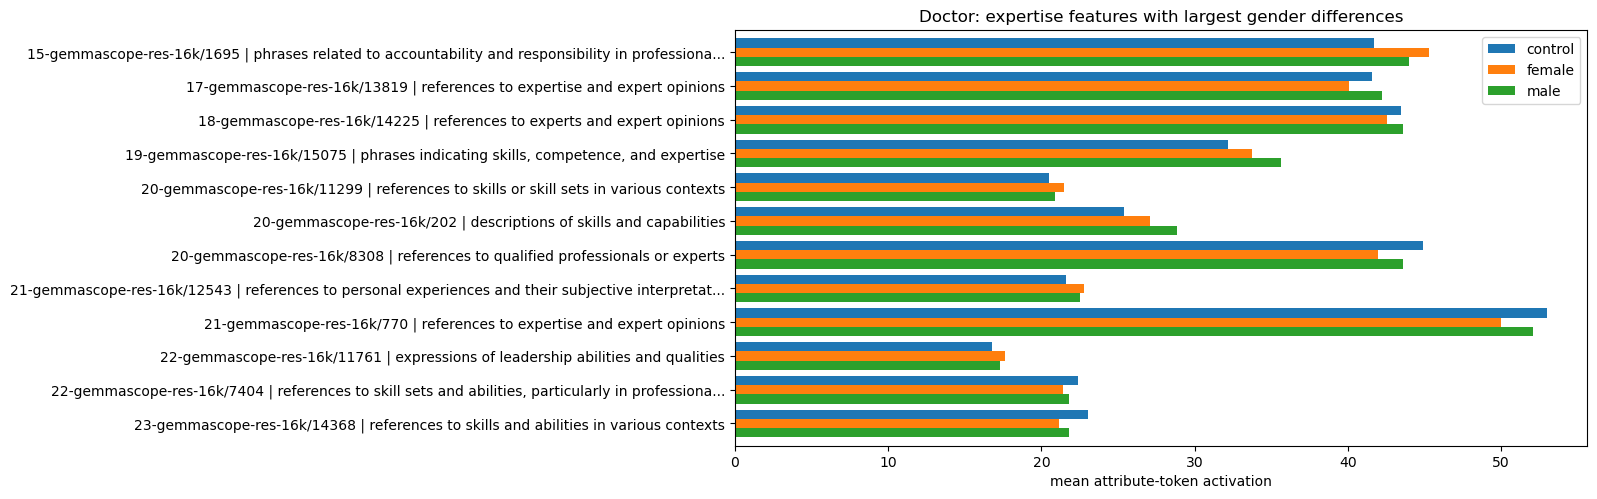

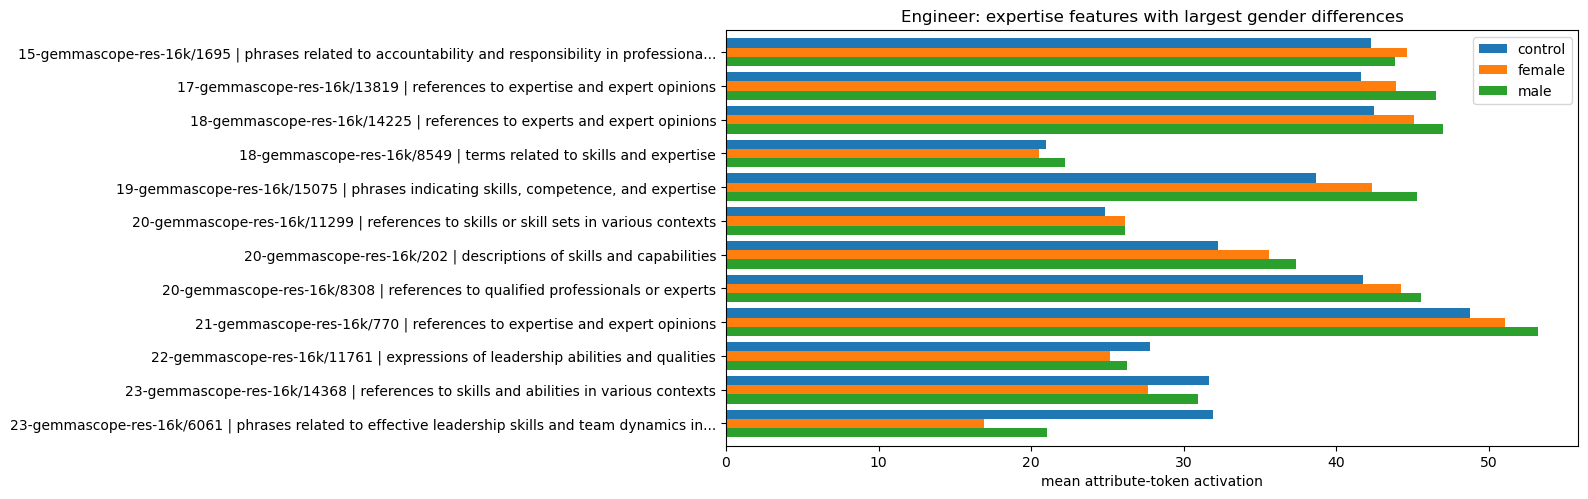

In [14]:
TOP_DIFFERENCE_FEATURES = 12


def short_label(row: pd.Series, max_description_chars: int = 70) -> str:
    description = str(row.get("description") or "").strip()
    if len(description) > max_description_chars:
        description = description[: max_description_chars - 3].rstrip() + "..."
    if description:
        return f"{row['feature']} | {description}"
    return str(row["feature"])


for profession, table in contrast_tables.items():
    top_difference_features = table.head(TOP_DIFFERENCE_FEATURES).copy()
    top_difference_features["label"] = top_difference_features.apply(short_label, axis=1)

    feature_difference_long = top_difference_features.melt(
        id_vars=[
            "feature",
            "label",
            "description",
            "expertise_prompt_count",
            "expertise_mean_activation",
            "male_minus_control",
            "female_minus_control",
            "male_minus_female",
            "spread",
        ],
        value_vars=[col for col in ["control", "male", "female"] if col in top_difference_features.columns],
        var_name="gender_group",
        value_name="mean_attribute_activation",
    )

    ax = feature_difference_long.pivot(
        index="label",
        columns="gender_group",
        values="mean_attribute_activation",
    ).plot.barh(
        figsize=(11, max(4, 0.45 * len(top_difference_features))),
        width=0.82,
        title=f"{profession.title()}: expertise features with largest gender differences",
    )
    ax.invert_yaxis()
    ax.set_xlabel("mean attribute-token activation")
    ax.set_ylabel("")
    ax.legend(title="")

    display(
        top_difference_features[
            [
                "feature",
                "description",
                "spread",
                "control",
                "male",
                "female",
                "male_minus_control",
                "female_minus_control",
                "male_minus_female",
                "expertise_prompt_count",
                "expertise_mean_activation",
            ]
        ]
    )

## 12. Gender Disparity Plots

These plots do not use group averages. For each feature, they compare matched male and female prompt pairs, keep only pairs where both activations are non-zero, then plot the single largest absolute male-female gap.

,feature,description,prompt_pair,male_minus_female,abs_male_female_gap,male,female,expertise_prompt_count,expertise_mean_activation
33,21-gemmascope-res-16k/770,references to expertise and expert opinions,capable_experienced,3.375,3.375,34.000,30.625,1,130.000
26,20-gemmascope-res-16k/8308,references to qualified professionals or experts,capable_experienced,3.250,3.250,26.000,22.750,1,109.000
17,19-gemmascope-res-16k/15075,"phrases indicating skills, competence, and expertise",skilled,3.000,3.000,45.250,42.250,4,64.125
4,17-gemmascope-res-16k/13819,references to expertise and expert opinions,capable_experienced,3.000,3.000,25.250,22.250,1,107.000
24,20-gemmascope-res-16k/202,descriptions of skills and capabilities,expert_qualified,2.750,2.750,22.875,20.125,3,64.750
1,15-gemmascope-res-16k/1695,phrases related to accountability and responsibility in professional or organizational contexts,competent,-2.250,2.250,43.500,45.750,2,44.125
8,18-gemmascope-res-16k/14225,references to experts and expert opinions,capable_experienced,2.000,2.000,29.625,27.625,1,105.500
18,19-gemmascope-res-16k/15421,references to personal experiences and the act of sharing them,capable_experienced,-1.500,1.500,91.500,93.000,1,111.000
45,23-gemmascope-res-16k/14368,references to skills and abilities in various contexts,skilled,1.500,1.500,72.500,71.000,1,108.500
13,18-gemmascope-res-16k/8784,terms related to experiences and their descriptions,capable_experienced,-1.500,1.500,91.500,93.000,1,108.000


,feature,description,prompt_pair,male_minus_female,abs_male_female_gap,male,female,expertise_prompt_count,expertise_mean_activation
62,19-gemmascope-res-16k/15075,"phrases indicating skills, competence, and expertise",competent,5.750,5.750,50.250,44.500,4,64.125
93,23-gemmascope-res-16k/6061,phrases related to effective leadership skills and team dynamics in a professional context,capable_experienced,4.000,4.000,26.375,22.375,2,48.875
70,20-gemmascope-res-16k/202,descriptions of skills and capabilities,competent,3.750,3.750,44.500,40.750,3,64.750
54,17-gemmascope-res-16k/13819,references to expertise and expert opinions,skilled,3.750,3.750,33.500,29.750,1,107.000
83,21-gemmascope-res-16k/770,references to expertise and expert opinions,skilled,3.000,3.000,28.875,25.875,1,130.000
57,18-gemmascope-res-16k/14225,references to experts and expert opinions,expert_qualified,2.500,2.500,96.000,93.500,1,105.500
84,22-gemmascope-res-16k/11761,expressions of leadership abilities and qualities,capable_experienced,2.375,2.375,28.375,26.000,2,47.625
78,21-gemmascope-res-16k/3268,references to skill sets and abilities,competent,2.125,2.125,15.125,13.000,1,96.500
76,20-gemmascope-res-16k/8308,references to qualified professionals or experts,skilled,2.000,2.000,22.000,20.000,1,109.000
88,22-gemmascope-res-16k/7404,"references to skill sets and abilities, particularly in professional contexts",competent,2.000,2.000,21.750,19.750,1,101.500


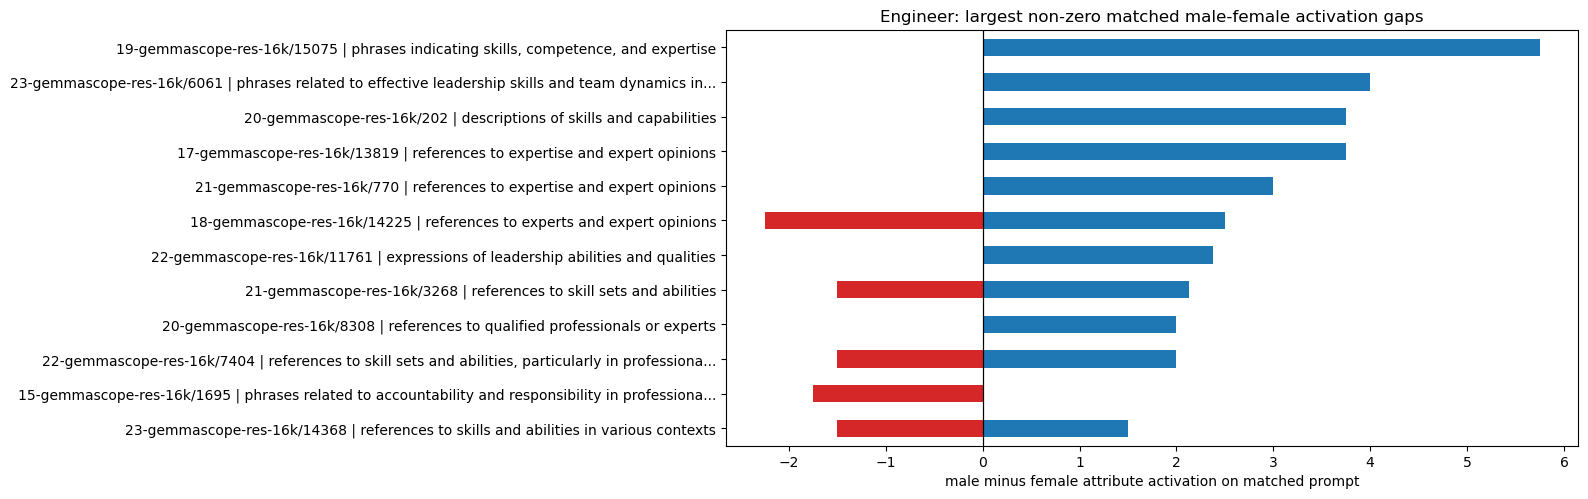

In [15]:
TOP_GENDER_DISPARITY_FEATURES = 12

pair_disparities = (
    activation_records[activation_records["gender_group"].isin(["male", "female"])]
    .pivot_table(
        index=[
            "profession",
            "feature",
            "source",
            "feature_index",
            "prompt_pair",
            "expertise_prompt_count",
            "expertise_mean_activation",
        ],
        columns="gender_group",
        values="attribute_activation",
        aggfunc="max",
        fill_value=0.0,
    )
    .reset_index()
)

pair_disparities = pair_disparities[
    (pair_disparities.get("male", 0.0) > 0)
    & (pair_disparities.get("female", 0.0) > 0)
].copy()

pair_disparities["male_minus_female"] = pair_disparities["male"] - pair_disparities["female"]
pair_disparities["abs_male_female_gap"] = pair_disparities["male_minus_female"].abs()
pair_disparities = pair_disparities.merge(
    feature_descriptions[["feature", "description"]],
    on="feature",
    how="left",
)

gender_disparity_tables = {}

for profession, frame in pair_disparities.groupby("profession"):
    idx = frame.groupby("feature")["abs_male_female_gap"].idxmax()
    disparity = (
        frame.loc[idx]
        .sort_values(["abs_male_female_gap", "expertise_prompt_count", "expertise_mean_activation"], ascending=[False, False, False])
        .head(TOP_GENDER_DISPARITY_FEATURES)
        .copy()
    )
    disparity["label"] = disparity.apply(short_label, axis=1)
    gender_disparity_tables[profession] = disparity

    colors = ["#1f77b4" if value >= 0 else "#d62728" for value in disparity["male_minus_female"]]
    ax = disparity.set_index("label")["male_minus_female"].plot.barh(
        figsize=(11, max(4, 0.45 * len(disparity))),
        color=colors,
        title=f"{profession.title()}: largest non-zero matched male-female activation gaps",
    )
    ax.axvline(0, color="black", linewidth=0.8)
    ax.invert_yaxis()
    ax.set_xlabel("male minus female attribute activation on matched prompt")
    ax.set_ylabel("")

    display(
        disparity[
            [
                "feature",
                "description",
                "prompt_pair",
                "male_minus_female",
                "abs_male_female_gap",
                "male",
                "female",
                "expertise_prompt_count",
                "expertise_mean_activation",
            ]
        ]
    )

## 13. Group Plot

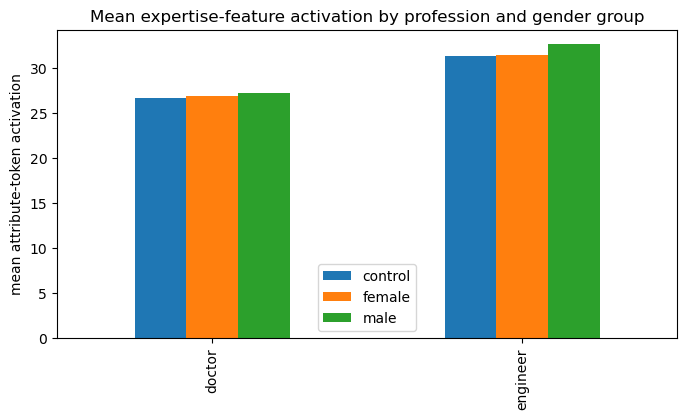

In [16]:
ax = group_summary.pivot(
    index="profession",
    columns="gender_group",
    values="mean_attribute_activation",
).plot.bar(
    figsize=(8, 4),
    title="Mean expertise-feature activation by profession and gender group",
)
ax.set_xlabel("")
ax.set_ylabel("mean attribute-token activation")
ax.legend(title="")

## 14. Interpretation

Use `group_summary` for overall averages, `contrast_tables` for per-profession feature tables, and `gender_disparity_tables` for the largest non-zero matched male-female activation gaps.